<a href="https://colab.research.google.com/github/Squad-Nina-da-Hora/wmc-desafio-carros-usados/blob/main/analise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Análise de Venda em Empresa de Veículos Usados**
---


🎯 **Objetivo específico:** Entender quais fatores mais impactam no preço de venda.

🎯 **Objetivo geral:** Identificar as variáveis mais relevantes e propor uma análise baseada em correlações e modelos preditivos simples.

---


Desafio Estatística com Python - Correlação e Regressão

Squad Nina da Hora | Bootcamp Data Analytics 2026.1

## 1. Configurações Iniciais

Variáveis da base de dados:

- `id`: Identificador único do veículo
- `make`: Marca do carro (ex: Ford, Toyota)
- `model`: Modelo do carro
- `year`: Ano de fabricação
- `price`: Preço de venda do carro
- `mileage`: Quilometragem (km rodados)
- `engine_size`: Tamanho do motor (em litros)
- `fuel_type`: Tipo de combustível (gasolina, diesel, elétrico)
- `transmission`: Tipo de transmissão (manual, automática)
- `doors`: Número de portas
- `color`: Cor do carro
- `tax`: Taxa anual de imposto veicular
- `mpg`: Milhas por Galão (indicador de eficiência de combustível)
- `sold_date`: Data de venda do veículo

In [3]:
# ==============================
# IMPORTACOES
# ==============================

import math  # Para funcoes matematicas, como calculo de tamanho de amostra
import numpy as np  # Para operacoes numericas e arrays
import pandas as pd  # Para manipulaco e analise de data frames
from IPython.display import display, Markdown  # Para exibir outputs formatados

# Bibliotecas para criacao de graficos
import seaborn as sns
import matplotlib.pyplot as plt

# Bibliotecas para testes estatisticos e de hipoteses
from scipy import stats
from scipy.stats import shapiro
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


# Carregamento da base de dados
arquivo = 'bd_carros_usados'
url = f'https://raw.githubusercontent.com/Squad-Nina-da-Hora/wmc-desafio-carros-usados/main/{arquivo}.csv'
df = pd.read_csv(url)

# Verifica se a coluna existe antes de tentar remover
if 'id' in df.columns:
  df.drop(columns='id', inplace=True) # Essa coluna nao tem utilidade

df.head()

,make,model,year,price,mileage,engine_size,fuel_type,transmission,doors,color,tax,mpg,sold_date
0,Volkswagen,Model B,2022,23859,94811,3.6,Diesel,Manual,2,Grey,288,39.2,2023-10-11
1,Chevrolet,Model A,2008,16953,128028,4.9,Diesel,Manual,5,Red,339,15.3,2021-04-22
2,BMW,Model B,2006,12332,49178,4.1,Diesel,Automatic,4,Red,458,37.2,2020-05-04
3,Chevrolet,Model B,2018,18475,42821,2.7,Hybrid,Manual,5,Silver,486,43.7,2021-06-20
4,Chevrolet,Model C,2017,12129,192799,2.8,Gasoline,Manual,4,Silver,295,19.1,2021-12-06


In [4]:
# ==============================
# VARIAVEIS PARA REUTILIZACAO
# ==============================

col_alvo = 'price'

# Armazena a paleta do Seaborn que sera usada em todo o trabalho
paleta = 'flare'
cores = sns.color_palette(paleta, n_colors=2)  # 2 cores fixas

In [5]:
# ==============================
# PERFIL DO DATASET
# ==============================

linhas = df.shape[0]
colunas = df.shape[1]
print(f"O dataset possui {linhas} linhas e {colunas} colunas.")

display(Markdown("---"))

info_df = pd.DataFrame({
    'Coluna': df.columns,
    'Tipo': df.dtypes.values,
    'Não nulos': df.count().values,
    'Nulos': df.isnull().sum().values,
    'Valores Únicos': df.nunique().values
})

info_df

O dataset possui 1000 linhas e 13 colunas.


---

,Coluna,Tipo,Não nulos,Nulos,Valores Únicos
0,make,str,1000,0,6
1,model,str,1000,0,4
2,year,int64,1000,0,18
3,price,int64,1000,0,976
4,mileage,int64,1000,0,995
5,engine_size,float64,1000,0,41
6,fuel_type,str,1000,0,4
7,transmission,str,1000,0,2
8,doors,int64,1000,0,4
9,color,str,1000,0,6


In [6]:
# ==============================
# FUNCOES PARA REUTILIZACAO
# ==============================

def estilizar_tabela(dados, paleta=paleta):
  """
  Estiliza a visualizacao do Data Frame
  """
  display(dados.style
          .format('{:.2f}')
          .background_gradient(cmap=sns.color_palette(paleta, as_cmap=True)))


def plotar_heatmap(dados, tamanho=[7,6], titulo=None, **kwargs):
  """
  Gera um grafico de calor (heatmap) estilizado utilizando Seaborn.

  Parametros:
    dados (DataFrame/Series): Matriz de dados ou correlacao a ser plotada.
    tamanho (list): Dimensoes do grafico no formato [largura, altura].
    titulo (str): Titulo que sera exibido no topo do grafico.
    **kwargs: Argumentos adicionais passados diretamente para a funcao sns.heatmap.
  """
  plt.figure(figsize=tamanho)
  plt.title(titulo, fontsize=12, fontweight='bold')
  sns.heatmap(dados, annot=True, cmap=paleta, fmt='.2f', linewidths=0.5, **kwargs)
  plt.tight_layout()
  plt.show()

---
# **PARTE 1: ANÁLISE DE CORRELAÇÃO**
---

 - Correlação entre as variáveis numéricas e o preço do carro (`price`).
 - Quais variáveis estão mais correlacionadas com o preço.
 - Quais estão menos correlacionadas.

In [7]:
df_numericas = df.select_dtypes(include=['number'])
print(f'Total de variáveis numéricas: {df_numericas.shape[1]}')

# Calcula a correlacao das variaveis numericas
df_corr = df_numericas.corr()
estilizar_tabela(df_corr) # Exibe a tabela estilizada

Total de variáveis numéricas: 7


,year,price,mileage,engine_size,doors,tax,mpg
year,1.00,-0.03,-0.02,-0.03,-0.00,-0.05,-0.05
price,-0.03,1.00,0.01,-0.00,0.03,0.01,-0.01
mileage,-0.02,0.01,1.00,0.01,0.04,0.05,-0.03
engine_size,-0.03,-0.00,0.01,1.00,-0.03,-0.02,-0.07
doors,-0.00,0.03,0.04,-0.03,1.00,0.04,-0.05
tax,-0.05,0.01,0.05,-0.02,0.04,1.00,-0.01
mpg,-0.05,-0.01,-0.03,-0.07,-0.05,-0.01,1.00


In [8]:
# Pega os indexes, ordenando os valores para o menor
id_corr_preco = df_corr[col_alvo].sort_values(ascending=False).index

# Calcula a correlacao da coluna 'price' com as colunas selecionadas
df_corr_preco = df_numericas[id_corr_preco].corrwith(df_numericas[col_alvo]).rename(col_alvo).to_frame()
df_corr_preco.round(2).T

,price,doors,mileage,tax,engine_size,mpg,year
price,1.0,0.03,0.01,0.01,-0.0,-0.01,-0.03


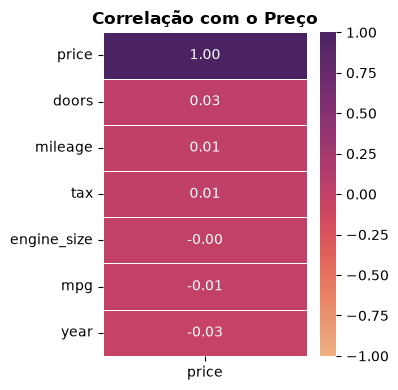

In [9]:
# Plota o grafico de correlacao (heatmap) com o preco
config_corr_price = {
  'vmin': -1,
  'vmax': 1,
}
plotar_heatmap(df_corr_preco,[4, 4], 'Correlação com o Preço', **config_corr_price)

### Variáveis mais relacionadas

In [10]:
# Cria ranking da correlacao das variaveis, baseado nos valores absolutos, decrescentemente

abs_corr_preco = df_corr_preco.abs().drop(col_alvo)
df_numericas_rank = abs_corr_preco.rank(ascending=False, method='dense').sort_values(by=col_alvo, ascending=True).rename(columns={col_alvo: 'rank'})
# Adiciona coluna com os valores de correlacao originais
df_numericas_rank['corr_value'] = df_corr_preco[col_alvo]
df_numericas_rank

,rank,corr_value
doors,1.0,0.033304
year,2.0,-0.033064
mileage,3.0,0.011115
tax,4.0,0.009043
mpg,5.0,-0.008201
engine_size,6.0,-0.000181


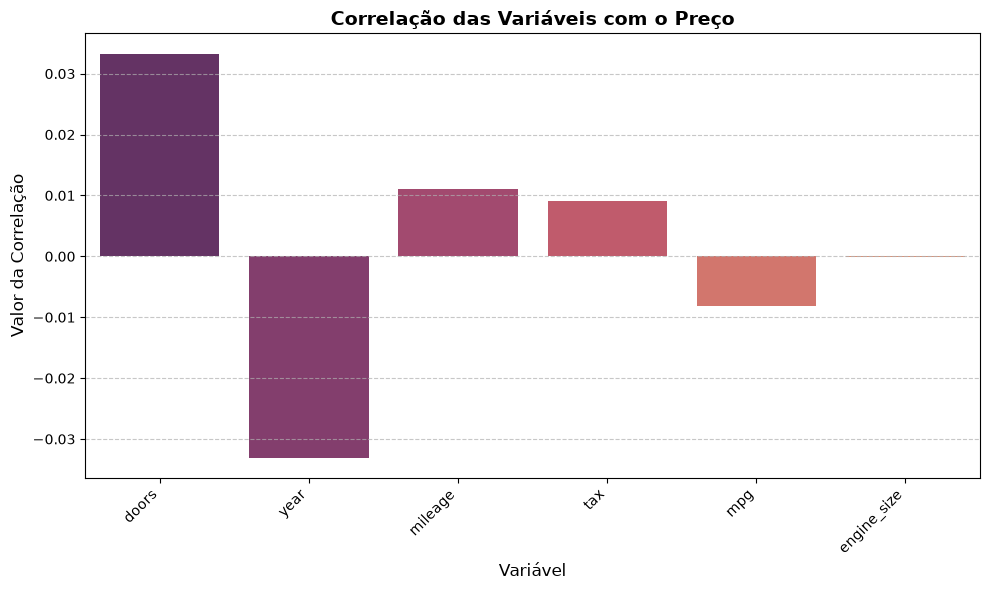

In [11]:
# Plota grafico de barras das correlacoes
plt.figure(figsize=(10, 6))
sns.barplot(x=df_numericas_rank.index, y='corr_value', data=df_numericas_rank, palette=paleta + '_r', hue=df_numericas_rank.index, legend=False)
plt.title('Correlação das Variáveis com o Preço', fontsize=14, fontweight='bold')
plt.xlabel('Variável', fontsize=12)
plt.ylabel('Valor da Correlação', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [12]:
top_mais_corr_preco = df_numericas_rank.head(3)
top_menos_corr_preco = df_numericas_rank.sort_values(by='rank', ascending=False).head(3)
display(Markdown(f'- **Variáveis MAIS relacionadas:** {top_mais_corr_preco.index.tolist()}\n- **Variáveis MENOS relacionadas:** {top_menos_corr_preco.index.tolist()}\n\n**Observação:** Nenhuma das variáveis numéricas tem impacto significativo no preço dos veículos.'))

- **Variáveis MAIS relacionadas:** ['doors', 'year', 'mileage']
- **Variáveis MENOS relacionadas:** ['engine_size', 'mpg', 'tax']

**Observação:** Nenhuma das variáveis numéricas tem impacto significativo no preço dos veículos.

---
# **PARTE 2: ANÁLISE DAS 5 VARIÁVEIS MAIS CORRELACIONADAS**
---

**Para as 5 variáveis com maior correlação com o preço:**
---

 - **Histograma** e **boxplot** de cada variável.
 - **Scatterplot** (gráfico de dispersão), com `price`no eixo **Y** e a variável no eixo **X**

### 📊 doors

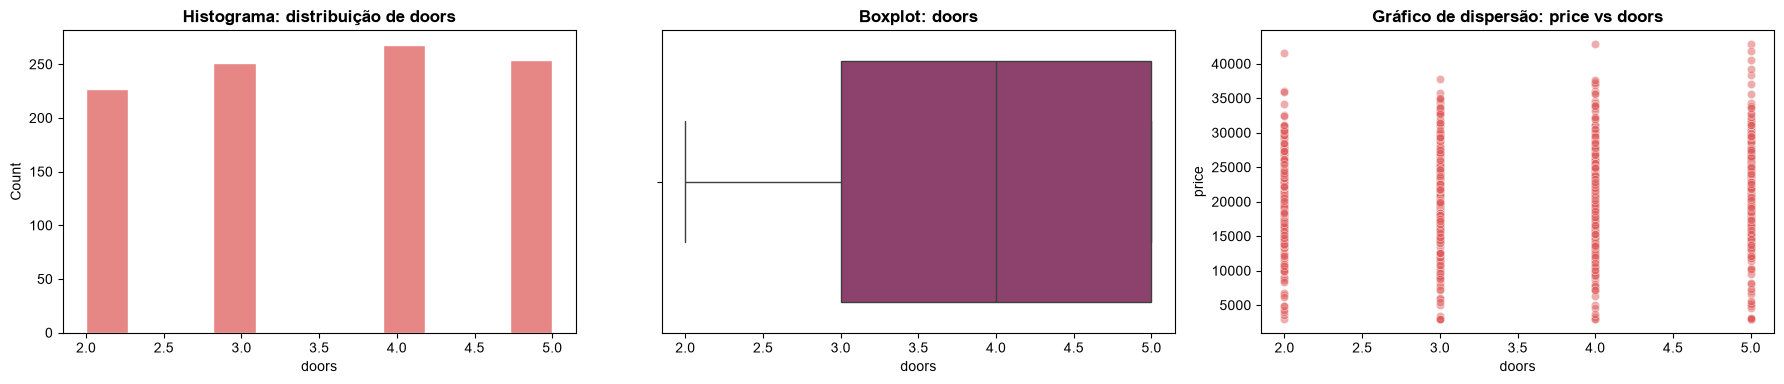

In [13]:
# 1ª variável

var1 = df_numericas_rank.index[0]

display(Markdown(f'### 📊 {var1}'))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.set_theme(style='whitegrid')

# Histograma
sns.histplot(data=df_numericas, x=var1, kde=False, ax=axes[0], color=cores[0])
axes[0].set_title(f'Histograma: distribuição de {var1}', fontweight='bold')

# Boxplot
sns.boxplot(data=df_numericas, x=var1, ax=axes[1], color=cores[1])
axes[1].set_title(f'Boxplot: {var1}', fontweight='bold')

# Dispersão vs Preço
sns.scatterplot(data=df_numericas, x=var1, y='price', alpha=0.5, ax=axes[2], color=cores[0])
axes[2].set_title(f'Gráfico de dispersão: price vs {var1}', fontweight='bold')

plt.tight_layout()
plt.show()

### 📊 year

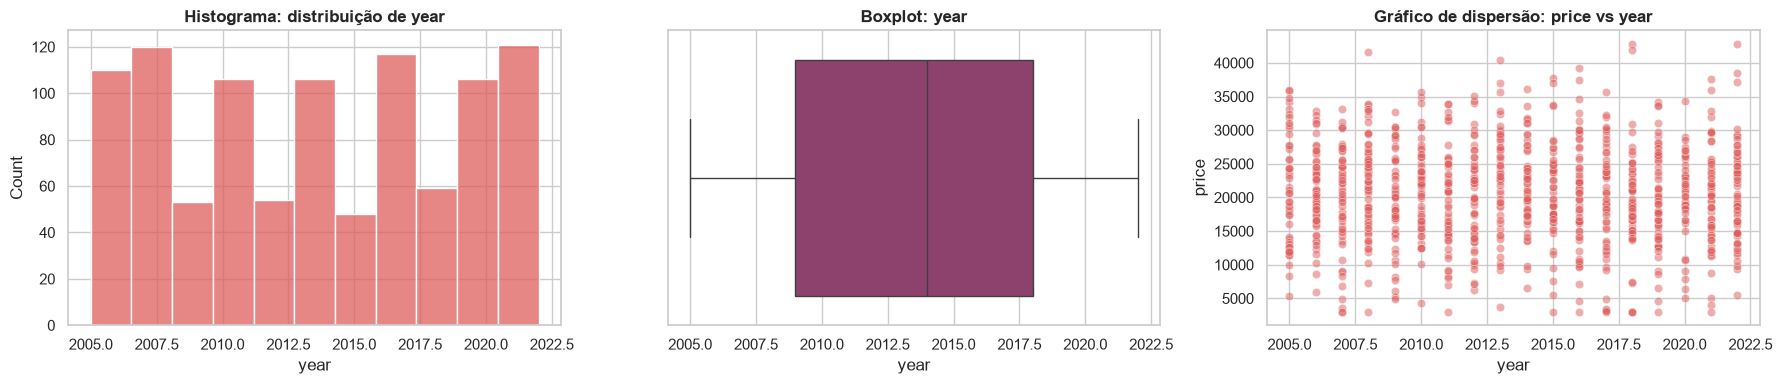

In [14]:
# 2ª variável

var2 = df_numericas_rank.index[1]

display(Markdown(f'### 📊 {var2}'))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.set_theme(style='whitegrid')

# Histograma
sns.histplot(data=df_numericas, x=var2, kde=False, ax=axes[0], color=cores[0])
axes[0].set_title(f'Histograma: distribuição de {var2}', fontweight='bold')

# Boxplot
sns.boxplot(data=df_numericas, x=var2, ax=axes[1], color=cores[1])
axes[1].set_title(f'Boxplot: {var2}', fontweight='bold')

# Dispersão vs Preço
sns.scatterplot(data=df_numericas, x=var2, y='price', alpha=0.5, ax=axes[2], color=cores[0])
axes[2].set_title(f'Gráfico de dispersão: price vs {var2}', fontweight='bold')

plt.tight_layout()
plt.show()

### 📊 mileage

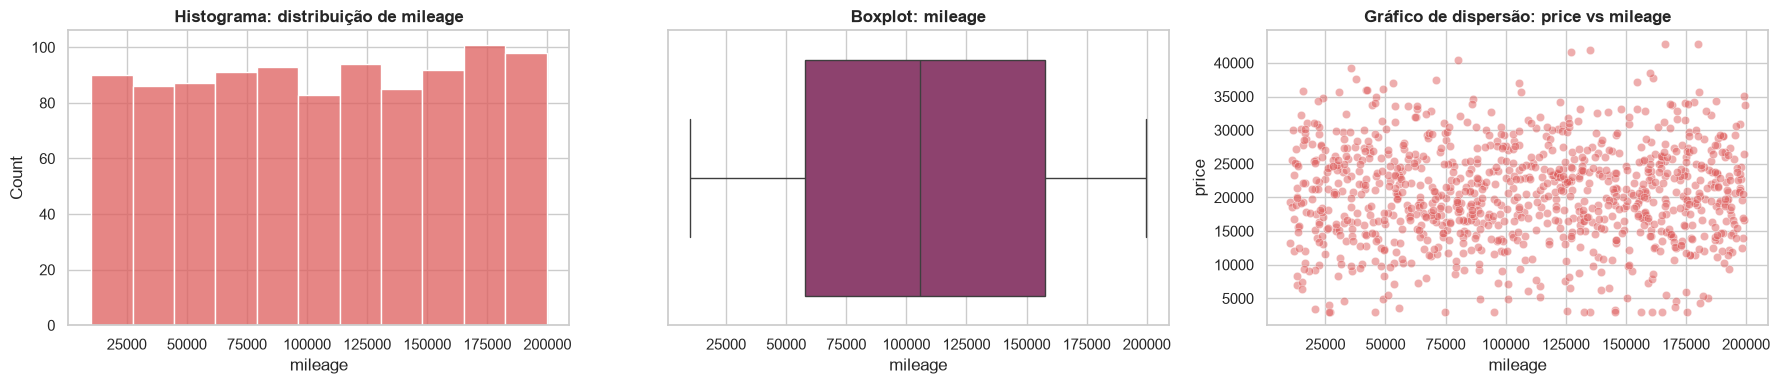

In [15]:
# 3ª variável

var3 = df_numericas_rank.index[2]

display(Markdown(f'### 📊 {var3}'))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.set_theme(style='whitegrid')

# Histograma
sns.histplot(data=df_numericas, x=var3, kde=False, ax=axes[0], color=cores[0])
axes[0].set_title(f'Histograma: distribuição de {var3}', fontweight='bold')

# Boxplot
sns.boxplot(data=df_numericas, x=var3, ax=axes[1], color=cores[1])
axes[1].set_title(f'Boxplot: {var3}', fontweight='bold')

# Dispersão vs Preço
sns.scatterplot(data=df_numericas, x=var3, y='price', alpha=0.5, ax=axes[2], color=cores[0])
axes[2].set_title(f'Gráfico de dispersão: price vs {var3}', fontweight='bold')

plt.tight_layout()
plt.show()

### 📊 tax

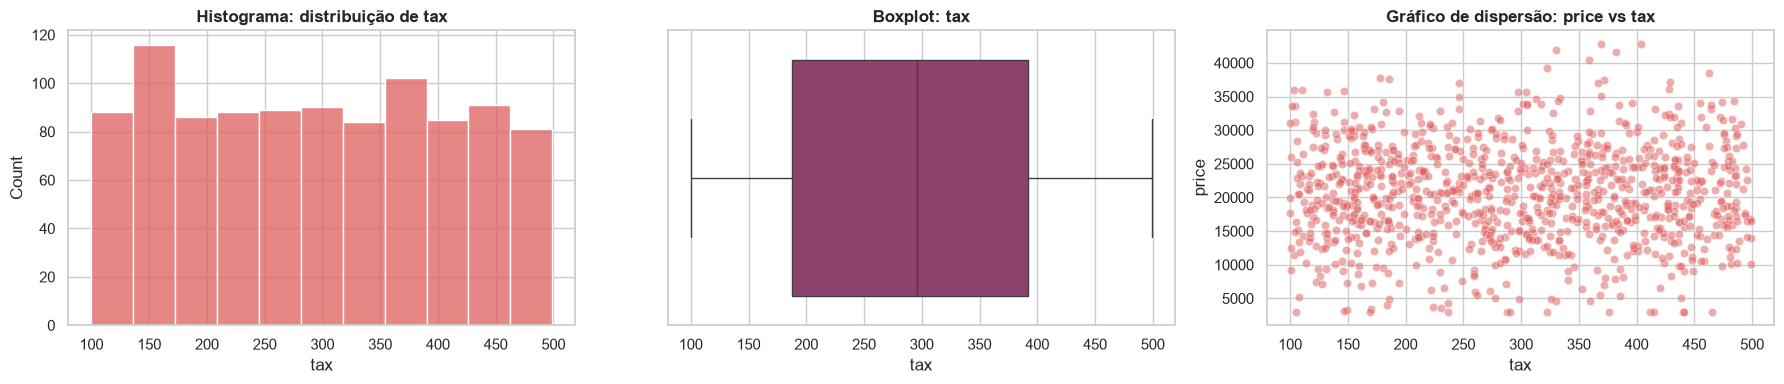

In [16]:
# 4ª variável: tax

var4 = df_numericas_rank.index[3]

display(Markdown(f'### 📊 {var4}'))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.set_theme(style='whitegrid')

# Histograma
sns.histplot(data=df_numericas, x=var4, kde=False, ax=axes[0], color=cores[0])
axes[0].set_title(f'Histograma: distribuição de {var4}', fontweight='bold')

# Boxplot
sns.boxplot(data=df_numericas, x=var4, ax=axes[1], color=cores[1])
axes[1].set_title(f'Boxplot: {var4}', fontweight='bold')

# Dispersão vs Preço
sns.scatterplot(data=df_numericas, x=var4, y='price', alpha=0.5, ax=axes[2], color=cores[0])
axes[2].set_title(f'Gráfico de dispersão: price vs {var4}', fontweight='bold')

plt.tight_layout()
plt.show()

### 📊 mpg

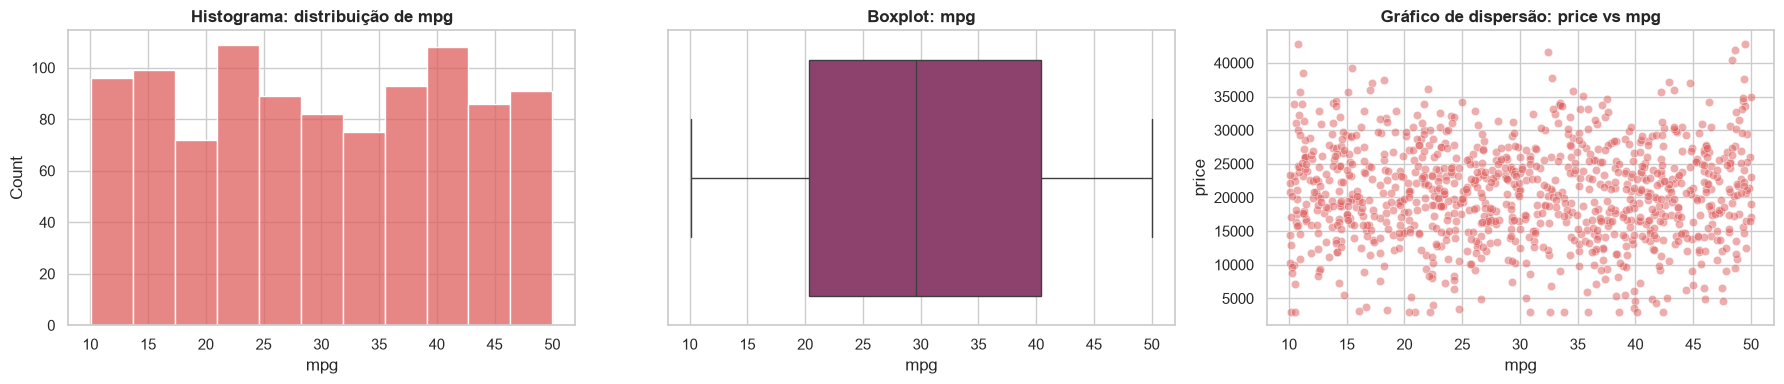

In [17]:
# 5ª variável: mpg

var5 = df_numericas_rank.index[4]

display(Markdown(f'### 📊 {var5}'))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.set_theme(style='whitegrid')

# Histograma
sns.histplot(data=df_numericas, x=var5, kde=False, ax=axes[0], color=cores[0])
axes[0].set_title(f'Histograma: distribuição de {var5}', fontweight='bold')

# Boxplot
sns.boxplot(data=df_numericas, x=var5, ax=axes[1], color=cores[1])
axes[1].set_title(f'Boxplot: {var5}', fontweight='bold')

# Dispersão vs Preço
sns.scatterplot(data=df_numericas, x=var5, y='price', alpha=0.5, ax=axes[2], color=cores[0])
axes[2].set_title(f'Gráfico de dispersão: price vs {var5}', fontweight='bold')

plt.tight_layout()
plt.show()

### 📊 engine_size

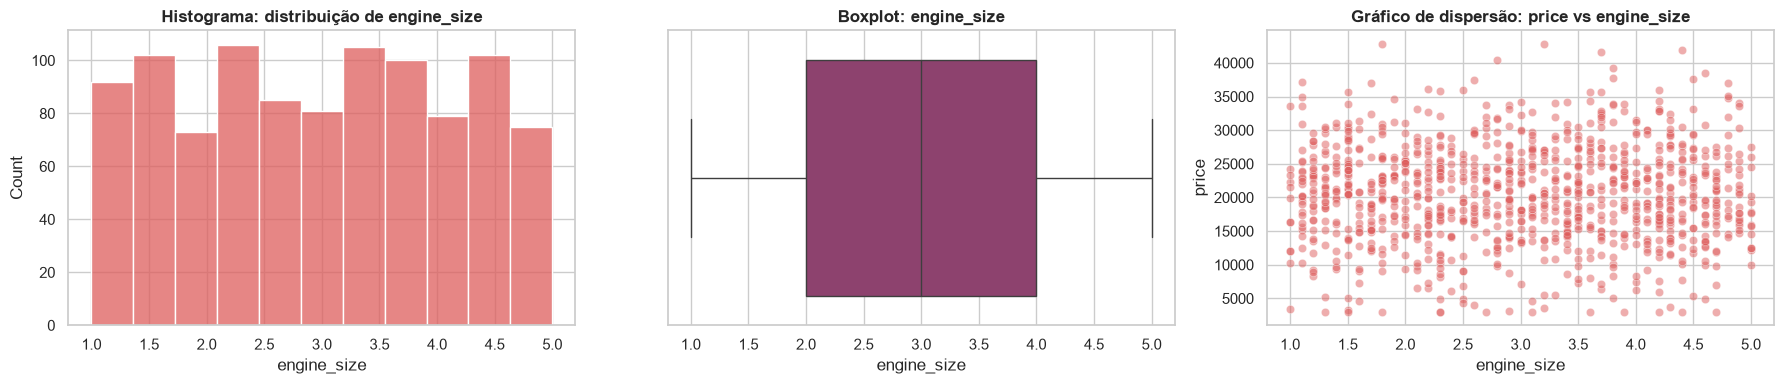

In [18]:
# 6ª variável: engine_size

var6 = df_numericas_rank.index[5]

display(Markdown(f'### 📊 {var6}'))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.set_theme(style='whitegrid')

# Histograma
sns.histplot(data=df_numericas, x=var6, kde=False, ax=axes[0], color=cores[0])
axes[0].set_title(f'Histograma: distribuição de {var6}', fontweight='bold')

# Boxplot
sns.boxplot(data=df_numericas, x=var6, ax=axes[1], color=cores[1])
axes[1].set_title(f'Boxplot: {var6}', fontweight='bold')

# Dispersão vs Preço
sns.scatterplot(data=df_numericas, x=var6, y='price', alpha=0.5, ax=axes[2], color=cores[0])
axes[2].set_title(f'Gráfico de dispersão: price vs {var6}', fontweight='bold')

plt.tight_layout()
plt.show()

 - **Regressão Linear Simples**, usando as variáveis mais correlacionadas como a variável preditora (**X**) e o preço como variável resposta (**Y**).
  - Interpretar os coeficientes e o R².

# **Extra:**

 - Análise feita a partir do mês de venda dos carros.

In [19]:
df['sold_date'] = pd.to_datetime(df['sold_date'])
df['sold_month'] = df['sold_date'].dt.month

print(df[['sold_date','sold_month']])
print(sorted(df['sold_month'].value_counts()))

     sold_date  sold_month
0   2023-10-11          10
1   2021-04-22           4
2   2020-05-04           5
3   2021-06-20           6
4   2021-12-06          12
..         ...         ...
995 2020-07-06           7
996 2023-04-29           4
997 2023-11-13          11
998 2023-05-23           5
999 2023-10-30          10

[1000 rows x 2 columns]
[71, 72, 73, 78, 79, 84, 88, 89, 90, 91, 91, 94]


---
# **Conclusão:**
---